# Model Analysis: Transformer + Nyström OC-SVM

Diagnostic analysis of the trained Transformer + Nyström OC-SVM detector (§5.1 of the report):
1. Inspect the internal OC-SVM state (gamma, rho, landmarks).
2. Compute latent-space statistics from the Transformer encoder.
3. Kernel sanity check: verify whether the RBF kernel is well-calibrated.
4. Nyström eigenvalue spectrum of $K_{CC}$.
5. Decision function distribution on test data (histogram).
6. Latent-space visualisation (PCA).
7. Reconstruction error vs. dissimilarity comparison.
8. Anomaly score distribution (histogram + KDE).

In [21]:
import os, sys, glob, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import joblib
from sklearn.decomposition import PCA

sys.path.insert(0, os.path.abspath(".."))

from detection.data.loaders import create_sequences as _create_sequences, load_processed
from detection.models.transformer import BottleneckTransformer
from detection.models.ocsvm import OCSVM

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## Configuration

In [22]:
DATA_DIR = os.path.join("..", "data", "processed", "TOTF.PA-book")
TRAIN_YEAR = "2017"  # "2015" or "2017"
RESULTS_DIR = os.path.join("..", "results", str(TRAIN_YEAR))

SEQ_LENGTH = 25
BATCH_SIZE = 512

# LOB columns present in processed files (not features)
LOB_COLUMNS = [
    f"{side}-{typ}-{lvl}"
    for lvl in range(1, 11)
    for side, typ in [("bid","price"),("bid","volume"),("ask","price"),("ask","volume")]
]

FILES = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
TEST_FILES = [FILES[22], FILES[23], FILES[24], FILES[25], FILES[26]]
print(f"Training year : {TRAIN_YEAR}")
print(f"Results dir   : {RESULTS_DIR}")
print(f"Test files    : {[os.path.basename(f) for f in TEST_FILES]}")

Training year : 2017
Results dir   : ..\results\2017
Test files    : ['2010-02-02-TOTF.PA-book.parquet', '2010-02-03-TOTF.PA-book.parquet', '2010-02-04-TOTF.PA-book.parquet', '2010-02-05-TOTF.PA-book.parquet', '2010-02-08-TOTF.PA-book.parquet']


## Load Feature Names

In [23]:
feat_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_features.txt")
if os.path.exists(feat_path):
    with open(feat_path) as f:
        feat_names = [line.strip() for line in f if line.strip()]
else:
    _, _feat_tmp = load_processed(TEST_FILES[0], "xltime", LOB_COLUMNS)
    feat_names = _feat_tmp.columns.tolist()
    del _feat_tmp

num_features = len(feat_names)
print(f"Features: {num_features}")
print(f"First 10: {feat_names[:10]}")

Features: 89
First 10: ['L1_Imbalance', 'L5_Imbalance', 'mid_price', 'spread', 'micro_price_deviation', 'bid_depth_ratio', 'ask_depth_ratio', 'log_return', 'bid_volume_delta', 'ask_volume_delta']


## Load Model and Test Data

Load the trained Transformer encoder, Nyström OC-SVM detector, and scaler.
Prepare latent representations from a test day for all downstream diagnostics.

In [24]:
# --- Load Transformer ---
weights_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_weights.pth")
transformer = BottleneckTransformer(
    num_features=num_features, model_dim=128, num_heads=8,
    num_layers=6, representation_dim=128, sequence_length=SEQ_LENGTH,
    dim_feedforward=512,
)
transformer.load_state_dict(torch.load(weights_path, map_location=DEVICE, weights_only=True))
transformer.eval().to(DEVICE)
print("Transformer loaded.")

# --- Load OC-SVM ---
ocsvm_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_detector.pth")
ocsvm = torch.load(ocsvm_path, map_location=DEVICE, weights_only=False)
print("OC-SVM loaded.")

# --- Load scaler ---
scaler_path = os.path.join(RESULTS_DIR, "transformer_ocsvm_scaler.pkl")
scaler = joblib.load(scaler_path)

# --- Prepare test data & latent representations ---
_, features_test = load_processed(TEST_FILES[0], "xltime", LOB_COLUMNS)
feat_df = features_test.copy()
for col in feat_names:
    if col not in feat_df.columns:
        feat_df[col] = 0.0
feat_df = feat_df[feat_names]

scaled = scaler.transform(feat_df.values.astype(np.float32)).astype(np.float32)
seqs = _create_sequences(scaled, SEQ_LENGTH)

# Encode ALL sequences for this test day
all_z = []
with torch.no_grad():
    for start in range(0, len(seqs), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(seqs))
        x_t = torch.tensor(seqs[start:end], dtype=torch.float32).to(DEVICE)
        z = transformer.get_representation(x_t)
        all_z.append(z.cpu())
z_all = torch.cat(all_z, dim=0)
print(f"Encoded {z_all.shape[0]} sequences -> latent dim {z_all.shape[1]}")

del features_test, feat_df

Transformer loaded.
OC-SVM loaded.
Encoded 213138 sequences -> latent dim 128


## 1. OC-SVM Internal State & Verification

Verify architecture and inspect OC-SVM parameters:
- Encoder output shape: `[batch, d_rep=128]`
- Nyström landmark count: `m=300`
- Gamma (RBF bandwidth), rho (offset), weight norm

In [25]:
EXPECTED_D_REP = 128
EXPECTED_NYSTROM_M = 300

# --- Verify Encoder ---
batch_test = 32
x_rand = torch.randn(batch_test, SEQ_LENGTH, num_features, device=DEVICE)
with torch.no_grad():
    z_rep = transformer.get_representation(x_rand)

print("=== Encoder Representation ===")
print(f"  Input  : {tuple(x_rand.shape)}  (batch, seq_len, d_in)")
print(f"  Output : {tuple(z_rep.shape)}  (batch, d_rep)")
assert z_rep.shape == (batch_test, EXPECTED_D_REP)
print(f"  ✓ d_rep = {EXPECTED_D_REP}")

# --- Verify Nyström landmarks ---
n_landmarks = ocsvm._landmarks.shape[0]
landmark_dim = ocsvm._landmarks.shape[1]
print(f"\n=== Nyström Landmarks ===")
print(f"  Shape : {tuple(ocsvm._landmarks.shape)}")
assert n_landmarks == EXPECTED_NYSTROM_M
assert landmark_dim == EXPECTED_D_REP
print(f"  ✓ m = {EXPECTED_NYSTROM_M}, dim = {EXPECTED_D_REP}")

# --- OC-SVM parameters ---
print(f"\n=== OC-SVM Parameters ===")
print(f"  γ (gamma)  : {ocsvm._gamma:.8f}")
print(f"  ρ (rho)    : {ocsvm._rho.item():.6f}")
print(f"  ||w||      : {ocsvm._w.norm().item():.6f}")
print(f"  # support  : {n_landmarks} (Nyström landmarks)")

del x_rand, z_rep

=== Encoder Representation ===
  Input  : (32, 25, 89)  (batch, seq_len, d_in)
  Output : (32, 128)  (batch, d_rep)
  ✓ d_rep = 128

=== Nyström Landmarks ===
  Shape : (300, 128)
  ✓ m = 300, dim = 128

=== OC-SVM Parameters ===
  γ (gamma)  : 0.00034931
  ρ (rho)    : -0.156572
  ||w||      : 0.202176
  # support  : 300 (Nyström landmarks)


## 2. Latent-Space Statistics

Mean, variance, and per-dimension statistics of the bottleneck representations $z \in \mathbb{R}^{128}$.
Histogram of latent values and per-dimension variance to check for collapsed or degenerate dimensions.

=== Latent Space Statistics ===
  Shape         : (213138, 128)
  Mean (global) : 0.191989


  Std (global)  : 4.651077
  Min           : -23.844807
  Max           : 22.702198
  Per-dim var   : min=6.877912, max=19.055046, mean=11.037079
  Dead dims (var < 1e-6): 0 / 128


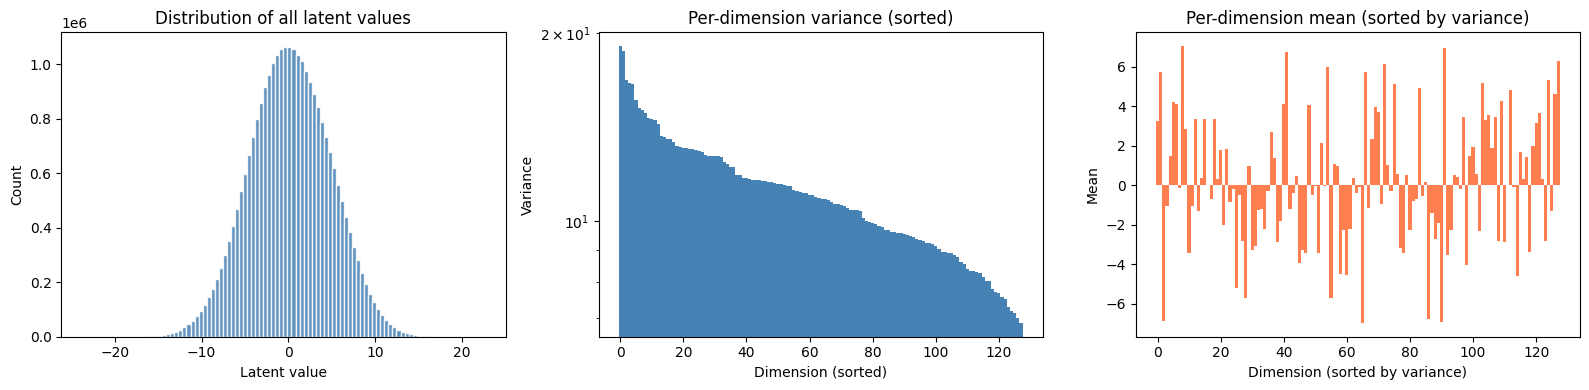

In [26]:
z_np = z_all.numpy()

print("=== Latent Space Statistics ===")
print(f"  Shape         : {z_np.shape}")
print(f"  Mean (global) : {z_np.mean():.6f}")
print(f"  Std (global)  : {z_np.std():.6f}")
print(f"  Min           : {z_np.min():.6f}")
print(f"  Max           : {z_np.max():.6f}")

# Per-dimension variance
dim_var = z_np.var(axis=0)
print(f"  Per-dim var   : min={dim_var.min():.6f}, max={dim_var.max():.6f}, mean={dim_var.mean():.6f}")
print(f"  Dead dims (var < 1e-6): {(dim_var < 1e-6).sum()} / {z_np.shape[1]}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram of all latent values
axes[0].hist(z_np.flatten(), bins=100, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Latent value")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of all latent values")

# Per-dimension variance bar plot
axes[1].bar(range(len(dim_var)), np.sort(dim_var)[::-1], color="steelblue", width=1.0)
axes[1].set_xlabel("Dimension (sorted)")
axes[1].set_ylabel("Variance")
axes[1].set_title("Per-dimension variance (sorted)")
axes[1].set_yscale("log")

# Per-dimension mean
dim_mean = z_np.mean(axis=0)
axes[2].bar(range(len(dim_mean)), dim_mean[np.argsort(-dim_var)], color="coral", width=1.0)
axes[2].set_xlabel("Dimension (sorted by variance)")
axes[2].set_ylabel("Mean")
axes[2].set_title("Per-dimension mean (sorted by variance)")

plt.tight_layout()
plt.show()

## 3. RBF Kernel Calibration

Verify that the RBF kernel $K(z_i, z_j) = \exp(-\gamma \|z_i - z_j\|^2)$ produces values in a discriminative range.
If all kernel values collapse near 0 or 1, the Nyström features are degenerate and the OC-SVM cannot separate inliers from outliers.

=== Kernel Calibration ===
  γ (gamma)              : 0.00034931
  d (latent dim)         : 128
  Var(z)                 : 21.632505
  E[||z_i - z_j||²]     : 5537.92
  Median ||z_i - z_j||² : 2703.35
  Typical K(z_i, z_j)   : 1.45e-01
  Median K(z_i, z_j)    : 3.89e-01
  Mean K(z_i, z_j)      : 3.90e-01
  % K < 0.01            : 0.0%
  % K > 0.99            : 0.0%


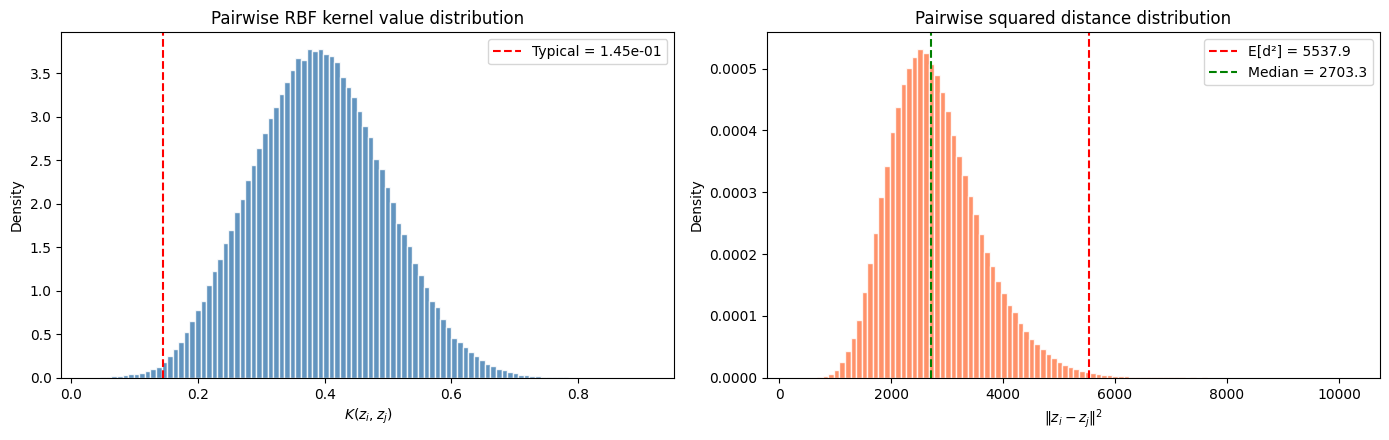

In [27]:
gamma = ocsvm._gamma

# Sample pairwise distances from the latent space
n_sample = min(1000, z_all.shape[0])
idx = np.random.choice(z_all.shape[0], n_sample, replace=False)
z_sample = z_all[idx]

# Compute pairwise squared distances
z_sq = (z_sample ** 2).sum(dim=1, keepdim=True)
dist2 = z_sq + z_sq.T - 2.0 * z_sample @ z_sample.T
dist2 = dist2.clamp(min=0.0)
# Extract upper triangle (unique pairs)
triu_idx = torch.triu_indices(n_sample, n_sample, offset=1)
dist2_pairs = dist2[triu_idx[0], triu_idx[1]].numpy()

# Kernel values
kernel_vals = np.exp(-gamma * dist2_pairs)

# Theoretical expected distance
d = z_all.shape[1]
var_z = z_all.var().item()
expected_dist2 = 2 * d * var_z
typical_kernel = np.exp(-gamma * expected_dist2)

print("=== Kernel Calibration ===")
print(f"  γ (gamma)              : {gamma:.8f}")
print(f"  d (latent dim)         : {d}")
print(f"  Var(z)                 : {var_z:.6f}")
print(f"  E[||z_i - z_j||²]     : {expected_dist2:.2f}")
print(f"  Median ||z_i - z_j||² : {np.median(dist2_pairs):.2f}")
print(f"  Typical K(z_i, z_j)   : {typical_kernel:.2e}")
print(f"  Median K(z_i, z_j)    : {np.median(kernel_vals):.2e}")
print(f"  Mean K(z_i, z_j)      : {np.mean(kernel_vals):.2e}")
print(f"  % K < 0.01            : {100*np.mean(kernel_vals < 0.01):.1f}%")
print(f"  % K > 0.99            : {100*np.mean(kernel_vals > 0.99):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Kernel value distribution
axes[0].hist(kernel_vals, bins=100, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].axvline(typical_kernel, color="red", linestyle="--", label=f"Typical = {typical_kernel:.2e}")
axes[0].set_xlabel("$K(z_i, z_j)$")
axes[0].set_ylabel("Density")
axes[0].set_title("Pairwise RBF kernel value distribution")
axes[0].legend()

# Pairwise distance distribution
axes[1].hist(dist2_pairs, bins=100, color="coral", edgecolor="white", alpha=0.85, density=True)
axes[1].axvline(expected_dist2, color="red", linestyle="--", label=f"E[d²] = {expected_dist2:.1f}")
axes[1].axvline(np.median(dist2_pairs), color="green", linestyle="--", label=f"Median = {np.median(dist2_pairs):.1f}")
axes[1].set_xlabel("$\\|z_i - z_j\\|^2$")
axes[1].set_ylabel("Density")
axes[1].set_title("Pairwise squared distance distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Nyström Eigenvalue Spectrum

Eigenvalues of the landmark kernel matrix $K_{CC}$ ($m \times m$).
A well-conditioned spectrum indicates that the Nyström approximation captures meaningful structure; rapid decay to near-zero suggests a good low-rank approximation.

=== Nyström Eigenvalue Spectrum ===
  Landmarks (m)          : 300
  λ_max                  : 112.1794
  λ_min (> 0)            : 8.2156e-02
  Condition number       : 1.37e+03
  Effective rank (95%)   : 207
  Effective rank (99%)   : 274


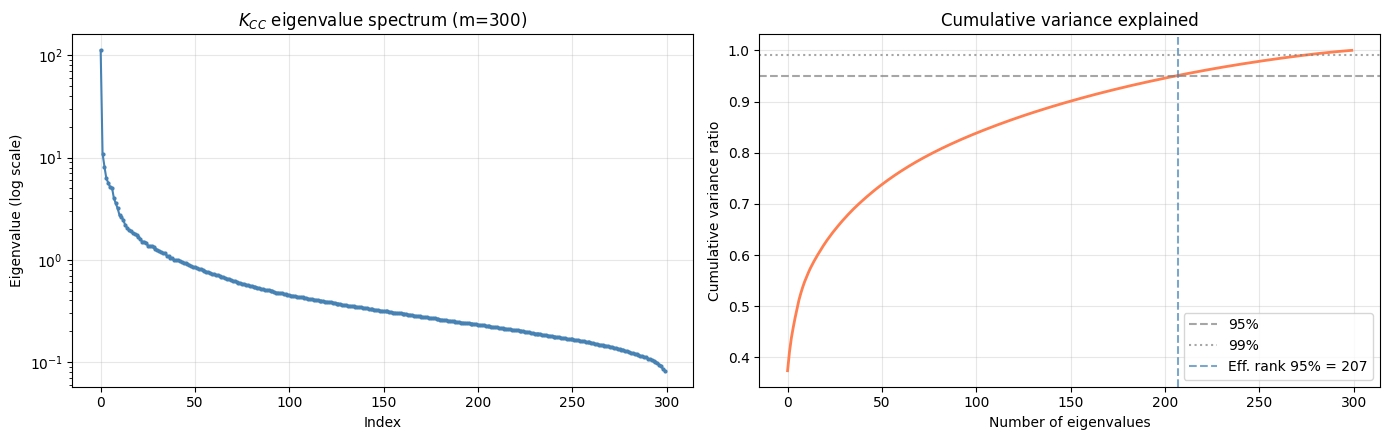

In [28]:
# Recompute K_CC from the stored landmarks
landmarks = ocsvm._landmarks
K_CC = ocsvm._rbf_kernel(landmarks, landmarks)
K_CC_np = K_CC.cpu().numpy()

# Eigendecomposition
eigvals = np.linalg.eigvalsh(K_CC_np)
eigvals = np.sort(eigvals)[::-1]  # descending

# Condition number and effective rank
eigvals_pos = eigvals[eigvals > 0]
condition_number = eigvals_pos[0] / eigvals_pos[-1] if len(eigvals_pos) > 1 else float('inf')
cumvar = np.cumsum(eigvals_pos) / np.sum(eigvals_pos)
effective_rank_95 = np.searchsorted(cumvar, 0.95) + 1
effective_rank_99 = np.searchsorted(cumvar, 0.99) + 1

print("=== Nyström Eigenvalue Spectrum ===")
print(f"  Landmarks (m)          : {landmarks.shape[0]}")
print(f"  λ_max                  : {eigvals[0]:.4f}")
print(f"  λ_min (> 0)            : {eigvals_pos[-1]:.4e}")
print(f"  Condition number       : {condition_number:.2e}")
print(f"  Effective rank (95%)   : {effective_rank_95}")
print(f"  Effective rank (99%)   : {effective_rank_99}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Eigenvalue spectrum (log scale)
axes[0].semilogy(eigvals_pos, 'o-', markersize=2, color="steelblue")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("Eigenvalue (log scale)")
axes[0].set_title(f"$K_{{CC}}$ eigenvalue spectrum (m={landmarks.shape[0]})")
axes[0].grid(True, alpha=0.3)

# Cumulative variance explained
axes[1].plot(cumvar, color="coral", linewidth=2)
axes[1].axhline(0.95, color="gray", linestyle="--", alpha=0.7, label="95%")
axes[1].axhline(0.99, color="gray", linestyle=":", alpha=0.7, label="99%")
axes[1].axvline(effective_rank_95, color="steelblue", linestyle="--", alpha=0.7, label=f"Eff. rank 95% = {effective_rank_95}")
axes[1].set_xlabel("Number of eigenvalues")
axes[1].set_ylabel("Cumulative variance ratio")
axes[1].set_title("Cumulative variance explained")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Decision Function Distribution

Histogram of the OC-SVM decision function $f(z) = w^\top \tilde{\Phi}(z) - \rho$ on test data.
Positive values → inliers; negative values → outliers.
The dissimilarity score is $-f(z)$.

=== Decision Function Distribution ===
  Samples       : 213138
  Mean f(z)     : 0.056626
  Std f(z)      : 0.011968
  Min f(z)      : 0.011878
  Max f(z)      : 0.108417
  ρ (rho)       : -0.156572
  Outliers      : 0 (0.00%)


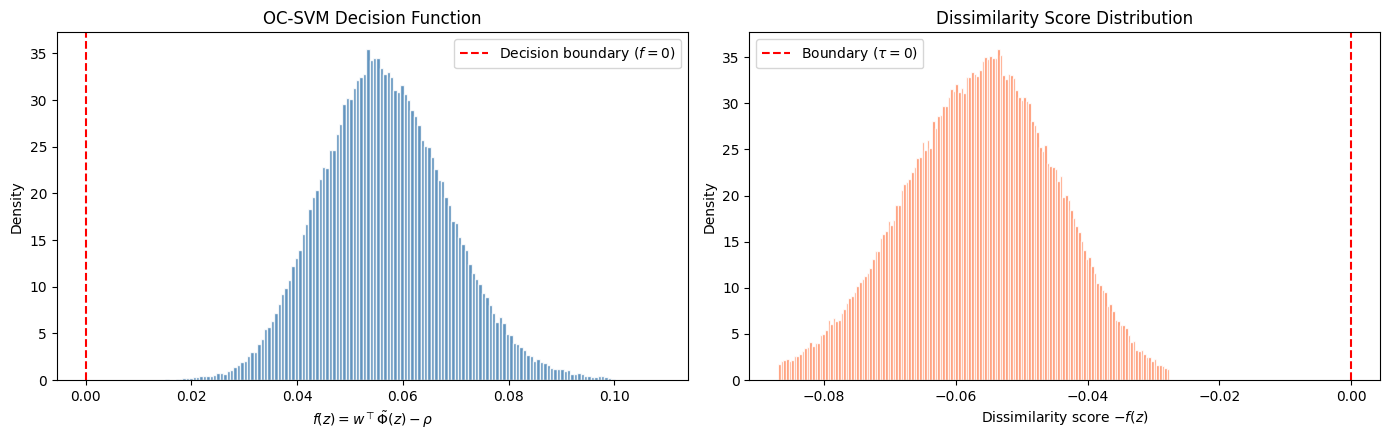

In [29]:
# Compute decision function and dissimilarity scores on test data
decision_vals = ocsvm.decision_function(z_all.numpy())
dissimilarity = -decision_vals

# Statistics
n_outliers = (decision_vals < 0).sum()
anomaly_rate = 100.0 * n_outliers / len(decision_vals)

print("=== Decision Function Distribution ===")
print(f"  Samples       : {len(decision_vals)}")
print(f"  Mean f(z)     : {decision_vals.mean():.6f}")
print(f"  Std f(z)      : {decision_vals.std():.6f}")
print(f"  Min f(z)      : {decision_vals.min():.6f}")
print(f"  Max f(z)      : {decision_vals.max():.6f}")
print(f"  ρ (rho)       : {ocsvm._rho.item():.6f}")
print(f"  Outliers      : {n_outliers} ({anomaly_rate:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Decision function histogram
axes[0].hist(decision_vals, bins=150, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Decision boundary ($f=0$)")
axes[0].set_xlabel("$f(z) = w^\\top \\tilde{\\Phi}(z) - \\rho$")
axes[0].set_ylabel("Density")
axes[0].set_title("OC-SVM Decision Function")
axes[0].legend()

# Dissimilarity score histogram (zoom on tails)
p1, p99 = np.percentile(dissimilarity, [1, 99.5])
axes[1].hist(dissimilarity, bins=150, color="coral", edgecolor="white", alpha=0.85, density=True,
             range=(p1, p99))
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Boundary ($\\tau=0$)")
axes[1].set_xlabel("Dissimilarity score $-f(z)$")
axes[1].set_ylabel("Density")
axes[1].set_title("Dissimilarity Score Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Reconstruction Error vs. Dissimilarity

Compare the Transformer reconstruction error $\|x - \hat{x}\|^2$ with the OC-SVM dissimilarity score.
Poutré et al. show that the dissimilarity approach outperforms reconstruction error alone. We visualise the joint distribution and correlation.

=== Reconstruction Error vs. Dissimilarity ===
  Pearson correlation    : -0.5003
  Rec. error mean       : 0.173844
  Rec. error std        : 0.091698
  Dissimilarity mean    : -0.056626
  Dissimilarity std     : 0.011968


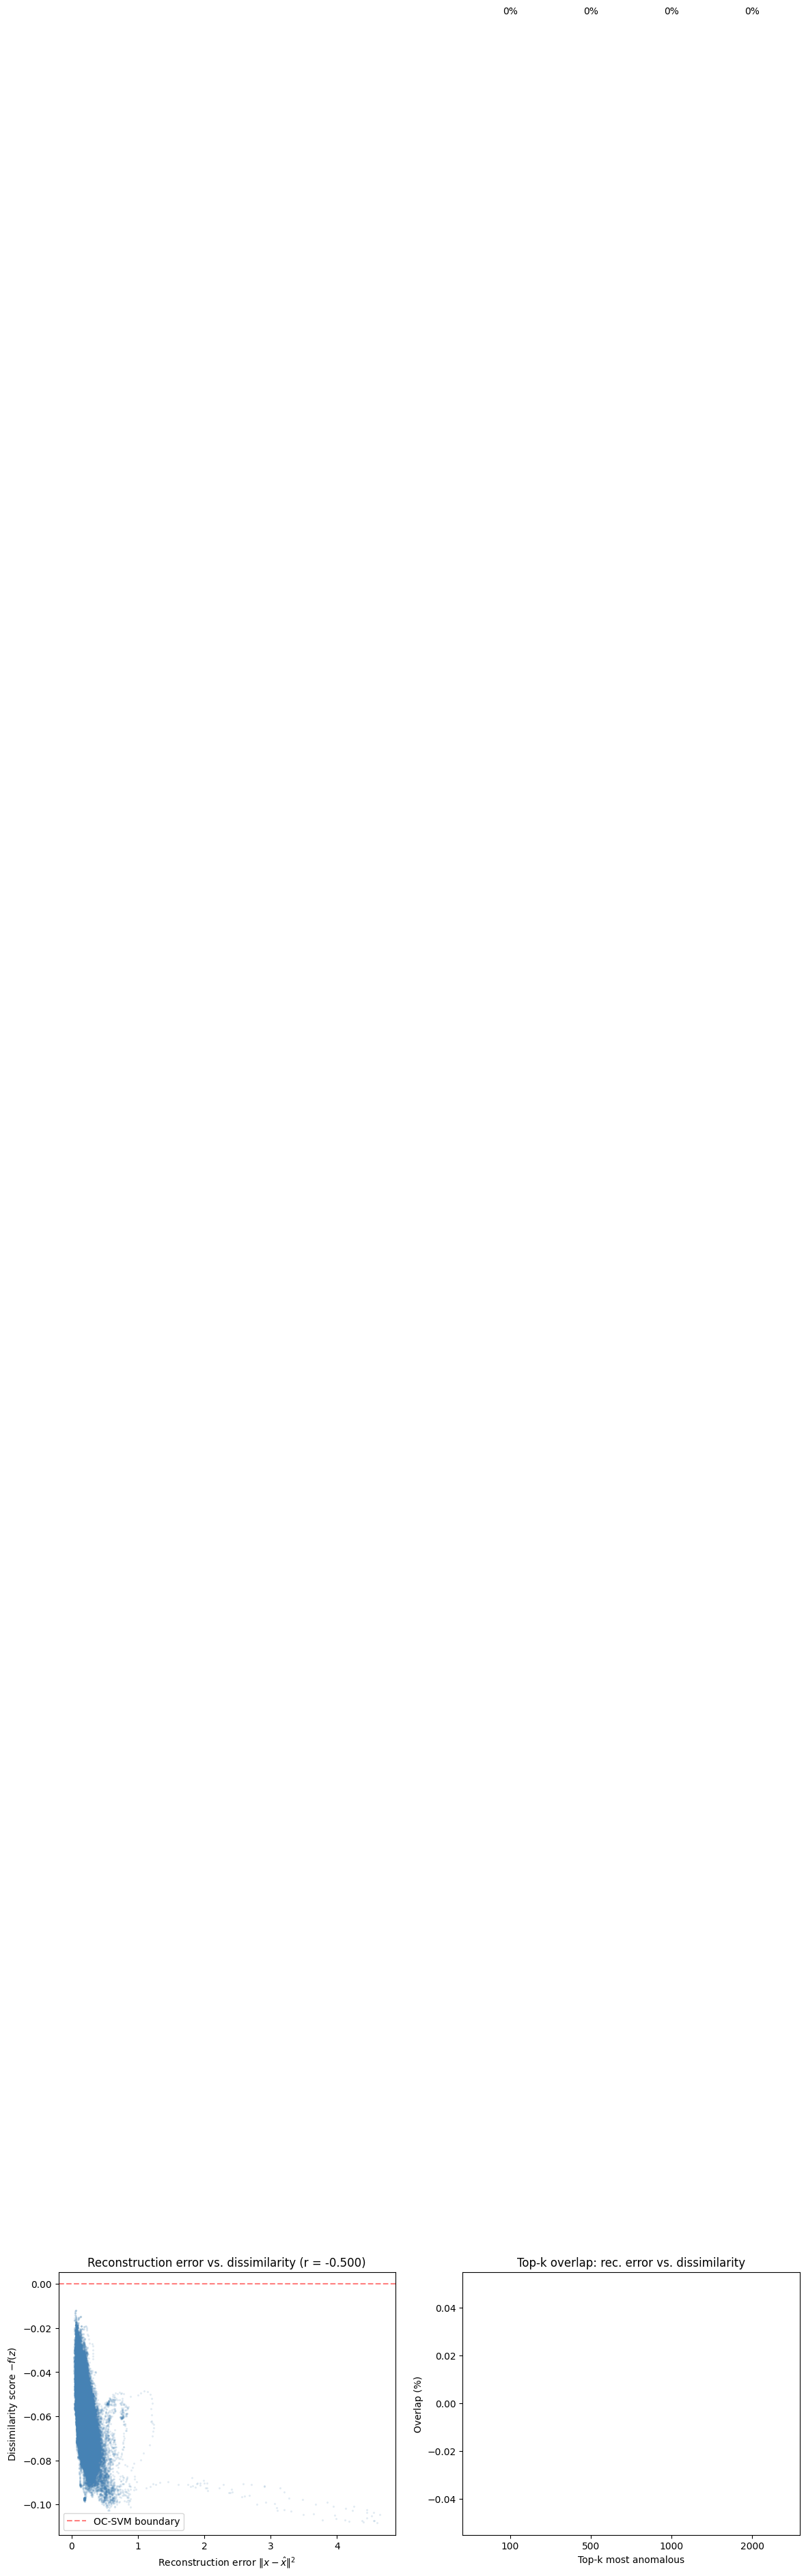

In [30]:
# Compute reconstruction errors
rec_errors = []
with torch.no_grad():
    for start in range(0, len(seqs), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(seqs))
        x_t = torch.tensor(seqs[start:end], dtype=torch.float32).to(DEVICE)
        x_hat = transformer(x_t)
        mse = ((x_hat - x_t) ** 2).mean(dim=(1, 2)).cpu().numpy()
        rec_errors.append(mse)
rec_errors = np.concatenate(rec_errors)

# Correlation
corr = np.corrcoef(rec_errors, dissimilarity)[0, 1]

print("=== Reconstruction Error vs. Dissimilarity ===")
print(f"  Pearson correlation    : {corr:.4f}")
print(f"  Rec. error mean       : {rec_errors.mean():.6f}")
print(f"  Rec. error std        : {rec_errors.std():.6f}")
print(f"  Dissimilarity mean    : {dissimilarity.mean():.6f}")
print(f"  Dissimilarity std     : {dissimilarity.std():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(rec_errors, dissimilarity, alpha=0.1, s=2, color="steelblue")
axes[0].set_xlabel("Reconstruction error $\\|x - \\hat{x}\\|^2$")
axes[0].set_ylabel("Dissimilarity score $-f(z)$")
axes[0].set_title(f"Reconstruction error vs. dissimilarity (r = {corr:.3f})")
axes[0].axhline(0, color="red", linestyle="--", alpha=0.5, label="OC-SVM boundary")
axes[0].legend()

# Rank comparison: % of anomalies shared in top-k
top_ks = [100, 500, 1000, 2000]
rank_rec = np.argsort(-rec_errors)
rank_dis = np.argsort(dissimilarity)[::-1]  # higher dissimilarity = more anomalous
overlaps = []
for k in top_ks:
    overlap = len(set(rank_rec[:k]) & set(rank_dis[:k])) / k * 100
    overlaps.append(overlap)

axes[1].bar([str(k) for k in top_ks], overlaps, color="coral", edgecolor="white")
axes[1].set_xlabel("Top-k most anomalous")
axes[1].set_ylabel("Overlap (%)")
axes[1].set_title("Top-k overlap: rec. error vs. dissimilarity")
for i, v in enumerate(overlaps):
    axes[1].text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Latent-Space Visualisation (PCA)

2D PCA projection of the bottleneck representations, coloured by dissimilarity score.
Points beyond the OC-SVM boundary (outliers) are highlighted.

PCA explained variance: 9.9% + 7.7% = 17.6%


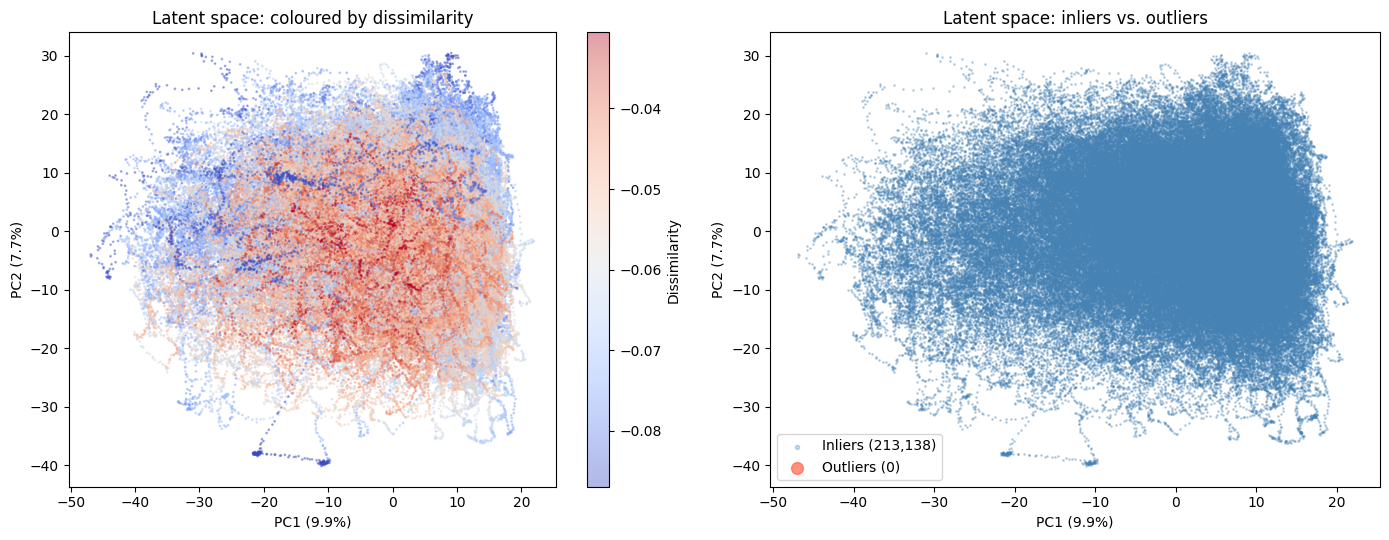

In [31]:
# PCA on latent representations
pca = PCA(n_components=2)
z_2d = pca.fit_transform(z_np)

is_outlier = decision_vals < 0

print(f"PCA explained variance: {pca.explained_variance_ratio_[0]:.1%} + {pca.explained_variance_ratio_[1]:.1%} = {sum(pca.explained_variance_ratio_):.1%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Colour by dissimilarity score
sc = axes[0].scatter(z_2d[:, 0], z_2d[:, 1], c=dissimilarity, cmap="coolwarm",
                     s=1, alpha=0.4, vmin=np.percentile(dissimilarity, 1),
                     vmax=np.percentile(dissimilarity, 99))
plt.colorbar(sc, ax=axes[0], label="Dissimilarity")
axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[0].set_title("Latent space: coloured by dissimilarity")

# Inliers vs outliers
axes[1].scatter(z_2d[~is_outlier, 0], z_2d[~is_outlier, 1], s=1, alpha=0.3,
                color="steelblue", label=f"Inliers ({(~is_outlier).sum():,})")
axes[1].scatter(z_2d[is_outlier, 0], z_2d[is_outlier, 1], s=8, alpha=0.7,
                color="tomato", label=f"Outliers ({is_outlier.sum():,})", zorder=5)
axes[1].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
axes[1].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
axes[1].set_title("Latent space: inliers vs. outliers")
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

## 8. Anomaly Score Distribution Across Test Days

Compute dissimilarity scores across all test files and display the aggregate distribution with summary statistics.
This feeds into `fig:score_distributions` in the report.

,File,Samples,Mean,Std,P95,P99,Anomalies,Rate (%)
0,2010-02-02-TOTF.PA-book.parquet,213138,-0.056626,0.011968,-0.037849,-0.030564,0,0.0
1,2010-02-03-TOTF.PA-book.parquet,220977,-0.067269,0.011483,-0.048544,-0.040329,0,0.0
2,2010-02-04-TOTF.PA-book.parquet,274271,-0.066487,0.012953,-0.044874,-0.035984,0,0.0
3,2010-02-05-TOTF.PA-book.parquet,371777,-0.074567,0.014014,-0.049568,-0.037347,0,0.0
4,2010-02-08-TOTF.PA-book.parquet,265576,-0.066358,0.012949,-0.044886,-0.036698,0,0.0


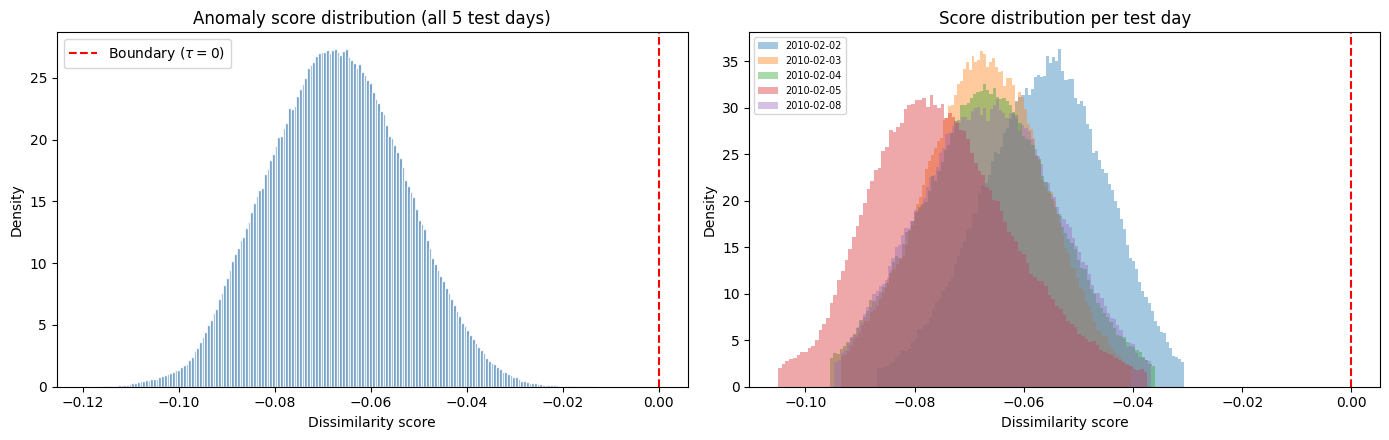

In [32]:
all_scores = {}
summary_rows = []

for fpath in TEST_FILES:
    fname = os.path.basename(fpath)
    _, feat_day = load_processed(fpath, "xltime", LOB_COLUMNS)
    feat_day_df = feat_day.copy()
    for col in feat_names:
        if col not in feat_day_df.columns:
            feat_day_df[col] = 0.0
    feat_day_df = feat_day_df[feat_names]

    scaled_day = scaler.transform(feat_day_df.values.astype(np.float32)).astype(np.float32)
    seqs_day = _create_sequences(scaled_day, SEQ_LENGTH)

    # Encode + dissimilarity
    z_parts = []
    with torch.no_grad():
        for start in range(0, len(seqs_day), BATCH_SIZE):
            end = min(start + BATCH_SIZE, len(seqs_day))
            x_t = torch.tensor(seqs_day[start:end], dtype=torch.float32).to(DEVICE)
            z_parts.append(transformer.get_representation(x_t).cpu().numpy())
    z_day = np.concatenate(z_parts, axis=0)
    scores_day = ocsvm.dissimilarity_score(z_day)
    all_scores[fname] = scores_day

    n_anom = (scores_day > 0).sum()
    summary_rows.append({
        "File": fname,
        "Samples": len(scores_day),
        "Mean": round(float(scores_day.mean()), 6),
        "Std": round(float(scores_day.std()), 6),
        "P95": round(float(np.percentile(scores_day, 95)), 6),
        "P99": round(float(np.percentile(scores_day, 99)), 6),
        "Anomalies": n_anom,
        "Rate (%)": round(100.0 * n_anom / len(scores_day), 3),
    })

    del feat_day, feat_day_df, scaled_day, seqs_day, z_day, scores_day

display(pd.DataFrame(summary_rows))

# Aggregate histogram
all_scores_flat = np.concatenate(list(all_scores.values()))
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(all_scores_flat, bins=200, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="Boundary ($\\tau=0$)")
axes[0].set_xlabel("Dissimilarity score")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Anomaly score distribution (all {len(TEST_FILES)} test days)")
axes[0].legend()

# Per-day overlay
for fname, scores in all_scores.items():
    p1, p99 = np.percentile(scores, [1, 99])
    axes[1].hist(scores, bins=100, alpha=0.4, density=True, label=fname[:10],
                 range=(p1, p99))
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("Dissimilarity score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score distribution per test day")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## 9. Baseline $\tau$ Analysis

The baseline threshold $\tau$ is the $(1 - \nu)$-th quantile (99th percentile) of dissimilarity scores
computed on the **training data** (first-hour blocks, first 5 days).

$$\tau = Q_{0.99}\bigl(\{-f(z_i)\}_{i \in \text{train}}\bigr)$$

An observation is flagged anomalous when $\text{dissimilarity}(z) \geq \tau$.

| Year | $\tau$ | Interpretation |
|------|--------|----------------|
| 2015 | $-0.019$ | Liberal — 99% of training scores fall below $-0.019$, all *inside* the boundary. Almost every test sample exceeds this. |
| 2017 | $+0.0002$ | Strict — 99th percentile is just above the boundary, so only genuine outliers are flagged. |

The sign of $\tau$ relative to the OC-SVM decision boundary ($f = 0$, i.e.\ dissimilarity $= 0$) is what matters:
- **$\tau < 0$**: threshold is inside the inlier region → flags both outliers *and* inlier-boundary samples → high detection rate
- **$\tau > 0$**: threshold is outside the boundary → only flags clear outliers → low detection rate

In [33]:
from detection.data.preprocessing import split_first_hour_blocks
from detection.models.ocsvm import OCSVM as OCSVMClass

CONTAMINATION = 0.01  # nu = 1%
NUM_TAU_DAYS = 5      # same as test.py

# Use ALL year files, pick first NUM_TRAIN_DAYS for training
YEAR_FILES = sorted(glob.glob(os.path.join(DATA_DIR, f"{TRAIN_YEAR}*.parquet")))
NUM_HOLDOUT = 12
NUM_TRAIN_DAYS = len(YEAR_FILES) - NUM_HOLDOUT
TRAIN_FILES = YEAR_FILES[:NUM_TRAIN_DAYS]

print(f"Year: {TRAIN_YEAR}")
print(f"Training files  : {NUM_TRAIN_DAYS} total, using first {NUM_TAU_DAYS} for tau")
print(f"Contamination   : {CONTAMINATION}")
print()

train_scores_all = []
transformer.eval()

with torch.no_grad():
    for tf in TRAIN_FILES[:NUM_TAU_DAYS]:
        try:
            df_day, feat_day = load_processed(tf, "xltime", LOB_COLUMNS)
            for c in feat_names:
                if c not in feat_day.columns:
                    feat_day[c] = 0.0
            feat_day = feat_day[feat_names]

            train_block, _ = split_first_hour_blocks(
                df_day["xltime"].values, feat_day, 9.0, 60, 5, 5)
            if len(train_block) < SEQ_LENGTH + 1:
                print(f"  {os.path.basename(tf)}: too few samples ({len(train_block)}), skipping")
                continue

            scaled_block = scaler.transform(
                train_block.values.astype(np.float32)).astype(np.float32)
            seqs_block = _create_sequences(scaled_block, SEQ_LENGTH)
            if len(seqs_block) == 0:
                continue

            # Encode -> dissimilarity
            z_parts = []
            for start in range(0, len(seqs_block), BATCH_SIZE):
                end = min(start + BATCH_SIZE, len(seqs_block))
                x_t = torch.tensor(seqs_block[start:end], dtype=torch.float32).to(DEVICE)
                z_parts.append(transformer.get_representation(x_t).cpu().numpy())
            z_block = np.concatenate(z_parts)
            scores_block = ocsvm.dissimilarity_score(z_block)
            train_scores_all.append(scores_block)
            print(f"  {os.path.basename(tf)}: {len(scores_block)} scores, "
                  f"mean={scores_block.mean():.6f}, P99={np.percentile(scores_block, 99):.6f}")
        except Exception as e:
            print(f"  {os.path.basename(tf)}: ERROR {e}")

if train_scores_all:
    all_train = np.concatenate(train_scores_all)
    tau = OCSVMClass.fit_baseline_tau(all_train, CONTAMINATION)
    print(f"\n=== Baseline τ ===")
    print(f"  τ = {tau:.6f}  (P{100*(1-CONTAMINATION):.0f} of {len(all_train)} training scores)")
    print(f"  Sign: {'POSITIVE (strict)' if tau > 0 else 'NEGATIVE (liberal)'}")
    print(f"  Interpretation: {'Only genuine outliers flagged' if tau > 0 else 'Many inlier-boundary samples also flagged'}")
else:
    tau = 0.0
    print("WARNING: Could not compute tau; defaulting to 0.0")

Year: 2017
Training files  : 61 total, using first 5 for tau
Contamination   : 0.01

  2017-01-02-TOTF.PA-book.parquet: 10920 scores, mean=-0.037530, P99=-0.002550
  2017-01-03-TOTF.PA-book.parquet: 25365 scores, mean=-0.032750, P99=-0.000560
  2017-01-04-TOTF.PA-book.parquet: 20868 scores, mean=-0.032067, P99=-0.001685
  2017-01-05-TOTF.PA-book.parquet: 18236 scores, mean=-0.031047, P99=0.000911
  2017-01-06-TOTF.PA-book.parquet: 22289 scores, mean=-0.029579, P99=0.002021

=== Baseline τ ===
  τ = 0.000179  (P99 of 97678 training scores)
  Sign: POSITIVE (strict)
  Interpretation: Only genuine outliers flagged


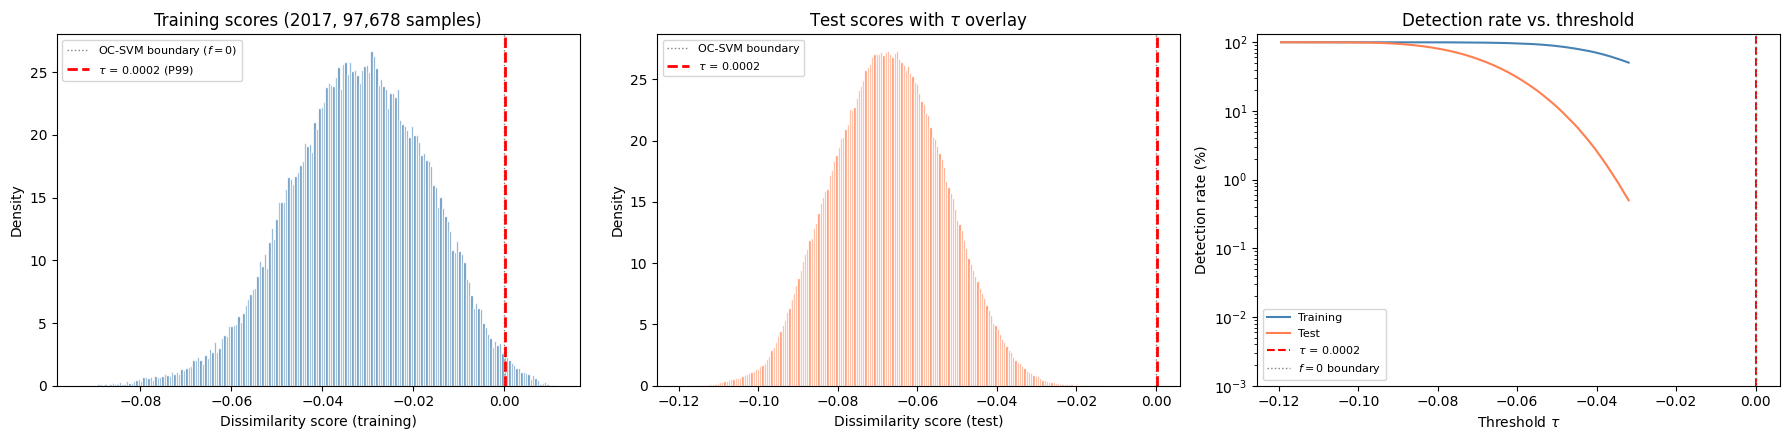

=== Anomaly rates at various thresholds ===
  baseline τ=0.0002             : train=  1.00%  test=  0.00%
  boundary (τ=0)                : train=  1.05%  test=  0.00%
  test P99                      : train= 58.48%  test=  1.00%
  test P95                      : train= 78.23%  test=  5.00%


In [34]:
# Visualise where tau falls on training and test score distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# --- Training score distribution ---
axes[0].hist(all_train, bins=200, color="steelblue", edgecolor="white", alpha=0.85, density=True)
axes[0].axvline(0, color="gray", linestyle=":", linewidth=1, label="OC-SVM boundary ($f=0$)")
axes[0].axvline(tau, color="red", linestyle="--", linewidth=2,
                label=f"$\\tau$ = {tau:.4f} (P{100*(1-CONTAMINATION):.0f})")
axes[0].set_xlabel("Dissimilarity score (training)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"Training scores ({TRAIN_YEAR}, {len(all_train):,} samples)")
axes[0].legend(fontsize=8)

# --- Test score distribution with tau ---
axes[1].hist(all_scores_flat, bins=200, color="coral", edgecolor="white", alpha=0.85, density=True)
axes[1].axvline(0, color="gray", linestyle=":", linewidth=1, label="OC-SVM boundary")
axes[1].axvline(tau, color="red", linestyle="--", linewidth=2,
                label=f"$\\tau$ = {tau:.4f}")
axes[1].set_xlabel("Dissimilarity score (test)")
axes[1].set_ylabel("Density")
axes[1].set_title(f"Test scores with $\\tau$ overlay")
axes[1].legend(fontsize=8)

# --- Detection rates at different thresholds ---
taus_sweep = np.linspace(
    min(all_train.min(), all_scores_flat.min()),
    np.percentile(all_scores_flat, 99.5), 500)
rates_train = [100.0 * np.mean(all_train >= t) for t in taus_sweep]
rates_test = [100.0 * np.mean(all_scores_flat >= t) for t in taus_sweep]

axes[2].plot(taus_sweep, rates_train, label="Training", color="steelblue", linewidth=1.5)
axes[2].plot(taus_sweep, rates_test, label="Test", color="coral", linewidth=1.5)
axes[2].axvline(tau, color="red", linestyle="--", linewidth=1.5, label=f"$\\tau$ = {tau:.4f}")
axes[2].axvline(0, color="gray", linestyle=":", linewidth=1, label="$f=0$ boundary")
axes[2].set_xlabel("Threshold $\\tau$")
axes[2].set_ylabel("Detection rate (%)")
axes[2].set_title("Detection rate vs. threshold")
axes[2].legend(fontsize=8)
axes[2].set_yscale("log")
axes[2].set_ylim(bottom=0.001)

plt.tight_layout()
plt.show()

# Summary table: anomaly rates at different tau choices
print("=== Anomaly rates at various thresholds ===")
for t_val, t_name in [(tau, f"baseline τ={tau:.4f}"), (0.0, "boundary (τ=0)"),
                       (np.percentile(all_scores_flat, 99), "test P99"),
                       (np.percentile(all_scores_flat, 95), "test P95")]:
    rate_train = 100.0 * np.mean(all_train >= t_val)
    rate_test = 100.0 * np.mean(all_scores_flat >= t_val)
    print(f"  {t_name:30s}: train={rate_train:6.2f}%  test={rate_test:6.2f}%")

## 10. Cross-Year $\tau$ Comparison

Load the other year's model and compute its tau on the same basis.
This explains the different detection behaviour between 2015-trained and 2017-trained models.

In [35]:
OTHER_YEAR = "2015" if TRAIN_YEAR == "2017" else "2017"
OTHER_DIR = os.path.join("..", "results", OTHER_YEAR)

other_weights = os.path.join(OTHER_DIR, "transformer_ocsvm_weights.pth")
other_detector = os.path.join(OTHER_DIR, "transformer_ocsvm_detector.pth")
other_scaler_path = os.path.join(OTHER_DIR, "transformer_ocsvm_scaler.pkl")
other_feat_path = os.path.join(OTHER_DIR, "transformer_ocsvm_features.txt")

results = {TRAIN_YEAR: {"tau": tau, "rho": ocsvm._rho.item(), "gamma": ocsvm._gamma,
                         "w_norm": ocsvm._w.norm().item(),
                         "train_mean": float(all_train.mean()),
                         "train_std": float(all_train.std()),
                         "train_p99": float(np.percentile(all_train, 99))}}

if os.path.exists(other_weights) and os.path.exists(other_detector):
    # Load other year's model
    with open(other_feat_path) as f:
        other_feat_names = [line.strip() for line in f if line.strip()]

    other_transformer = BottleneckTransformer(
        num_features=len(other_feat_names), model_dim=128, num_heads=8,
        num_layers=6, representation_dim=128, sequence_length=SEQ_LENGTH,
        dim_feedforward=512,
    )
    other_transformer.load_state_dict(
        torch.load(other_weights, map_location=DEVICE, weights_only=True))
    other_transformer.eval().to(DEVICE)

    other_ocsvm = torch.load(other_detector, map_location=DEVICE, weights_only=False)
    other_scaler = joblib.load(other_scaler_path)

    # Compute tau on OTHER year's training data
    other_year_files = sorted(glob.glob(os.path.join(DATA_DIR, f"{OTHER_YEAR}*.parquet")))
    other_train_files = other_year_files[:len(other_year_files) - NUM_HOLDOUT]

    other_train_scores = []
    with torch.no_grad():
        for tf in other_train_files[:NUM_TAU_DAYS]:
            try:
                df_day, feat_day = load_processed(tf, "xltime", LOB_COLUMNS)
                for c in other_feat_names:
                    if c not in feat_day.columns:
                        feat_day[c] = 0.0
                feat_day = feat_day[other_feat_names]

                train_block, _ = split_first_hour_blocks(
                    df_day["xltime"].values, feat_day, 9.0, 60, 5, 5)
                if len(train_block) < SEQ_LENGTH + 1:
                    continue

                scaled_block = other_scaler.transform(
                    train_block.values.astype(np.float32)).astype(np.float32)
                seqs_block = _create_sequences(scaled_block, SEQ_LENGTH)
                if len(seqs_block) == 0:
                    continue

                z_parts = []
                for start in range(0, len(seqs_block), BATCH_SIZE):
                    end = min(start + BATCH_SIZE, len(seqs_block))
                    x_t = torch.tensor(seqs_block[start:end], dtype=torch.float32).to(DEVICE)
                    z_parts.append(other_transformer.get_representation(x_t).cpu().numpy())
                z_block = np.concatenate(z_parts)
                scores_block = other_ocsvm.dissimilarity_score(z_block)
                other_train_scores.append(scores_block)
            except Exception as e:
                print(f"  {os.path.basename(tf)}: ERROR {e}")

    if other_train_scores:
        other_all = np.concatenate(other_train_scores)
        other_tau = OCSVMClass.fit_baseline_tau(other_all, CONTAMINATION)
        results[OTHER_YEAR] = {
            "tau": other_tau, "rho": other_ocsvm._rho.item(),
            "gamma": other_ocsvm._gamma, "w_norm": other_ocsvm._w.norm().item(),
            "train_mean": float(other_all.mean()),
            "train_std": float(other_all.std()),
            "train_p99": float(np.percentile(other_all, 99)),
        }

    del other_transformer, other_ocsvm, other_scaler

# Display comparison
comp_df = pd.DataFrame(results).T
comp_df.index.name = "Year"
display(comp_df.round(6))

print("\n=== Key Difference ===")
for yr, r in results.items():
    sign = "POSITIVE (strict)" if r["tau"] > 0 else "NEGATIVE (liberal)"
    pct_above_boundary = 100 * (1 - CONTAMINATION) if r["tau"] == r["train_p99"] else None
    print(f"  {yr}: τ = {r['tau']:+.6f}  [{sign}]")
    print(f"        ρ = {r['rho']:.6f}, γ = {r['gamma']:.8f}, ||w|| = {r['w_norm']:.6f}")
    print(f"        Training scores: mean = {r['train_mean']:.6f}, std = {r['train_std']:.6f}")
    print()

,tau,rho,gamma,w_norm,train_mean,train_std,train_p99
Year,,,,,,,
2017,0.000179,-0.156572,0.000349,0.202176,-0.032097,0.015234,0.000179
2015,-0.019052,0.183613,0.000490,0.654072,-0.204316,0.068858,-0.019052



=== Key Difference ===
  2017: τ = +0.000179  [POSITIVE (strict)]
        ρ = -0.156572, γ = 0.00034931, ||w|| = 0.202176
        Training scores: mean = -0.032097, std = 0.015234

  2015: τ = -0.019052  [NEGATIVE (liberal)]
        ρ = 0.183613, γ = 0.00049015, ||w|| = 0.654072
        Training scores: mean = -0.204316, std = 0.068858

